In [1]:
import argparse, json, math, sys
from typing import Iterable, List, Optional
import pandas as pd
import numpy as np

In [2]:
# SAMPLES_FILE_PATH = "/data/rasta/lm-evaluation-harness/results/Llama3.1_8b_0.1train_ppo_40ksteps/__data__qs4-data2__PPO-with-Confidence__models__PPO__Llama-3.1-8B-Instruct_ppo_DeepValueHead_simple_reward_steps30k_vfcoef0.5_lr5e-4_0.1sfttrain__policy_only/samples_nutribench_v2_baseline_2025-10-07T14-55-49.892043.jsonl"
# SAMPLES_FILE_PATHS = [
#     '/data/rasta/lm-evaluation-harness/results/Llama3.1_8b_0.1train_high_temp_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS2_E2_DF1.0_remove_cot/samples_nutribench_v2_baseline_2025-10-13T14-03-47.701823.jsonl',
#     '/data/rasta/lm-evaluation-harness/results/Llama3.1_8b_0.1train_high_temp_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS2_E2_DF1.0_remove_cot/samples_nutribench_v2_baseline_2025-10-13T13-55-32.335447.jsonl',
#     '/data/rasta/lm-evaluation-harness/results/Llama3.1_8b_0.1train_high_temp_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS2_E2_DF1.0_remove_cot/samples_nutribench_v2_baseline_2025-10-13T13-47-32.966680.jsonl',
#     '/data/rasta/lm-evaluation-harness/results/Llama3.1_8b_0.1train_high_temp_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS2_E2_DF1.0_remove_cot/samples_nutribench_v2_baseline_2025-10-13T13-38-46.851852.jsonl',
#     '/data/rasta/lm-evaluation-harness/results/Llama3.1_8b_0.1train_high_temp_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS2_E2_DF1.0_remove_cot/samples_nutribench_v2_baseline_2025-10-13T13-30-15.657621.jsonl'
# ]

# SAMPLES_FILE_PATHS = [
#     # '/data/rasta/lm-evaluation-harness/results/train_data_multiple_sample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS2_E2_DF1.0_remove_cot/samples_nutribench_v2_baseline_2025-10-15T09-33-32.512305.jsonl',
#     # '/data/rasta/lm-evaluation-harness/results/train_data_multiple_sample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS2_E2_DF1.0_remove_cot/samples_nutribench_v2_baseline_2025-10-15T09-48-58.117952.jsonl',
#     # '/data/rasta/lm-evaluation-harness/results/train_data_multiple_sample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS2_E2_DF1.0_remove_cot/samples_nutribench_v2_baseline_2025-10-15T10-05-27.177531.jsonl',
#     # '/data/rasta/lm-evaluation-harness/results/train_data_multiple_sample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS2_E2_DF1.0_remove_cot/samples_nutribench_v2_baseline_2025-10-15T10-21-43.815990.jsonl',
#     # '/data/rasta/lm-evaluation-harness/results/train_data_multiple_sample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS2_E2_DF1.0_remove_cot/samples_nutribench_v2_baseline_2025-10-15T10-38-12.091122.jsonl'
#     #### These were NUTRIBENCH =((()))
#     '/data/rasta/lm-evaluation-harness/results/dict_output_half_train_sft/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_nutribench_v2_baseline_2025-10-21T22-39-39.079012.jsonl',
#     '/data/rasta/lm-evaluation-harness/results/dict_output_half_train_sft/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_nutribench_v2_baseline_2025-10-21T22-30-34.356041.jsonl',
#     '/data/rasta/lm-evaluation-harness/results/dict_output_half_train_sft/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_nutribench_v2_baseline_2025-10-21T22-21-47.217942.jsonl',
#     '/data/rasta/lm-evaluation-harness/results/dict_output_half_train_sft/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_nutribench_v2_baseline_2025-10-21T22-12-32.574041.jsonl',
#     '/data/rasta/lm-evaluation-harness/results/dict_output_half_train_sft/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_nutribench_v2_baseline_2025-10-21T22-03-28.518241.jsonl',
#     '/data/rasta/lm-evaluation-harness/results/dict_output_half_train_sft/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_nutribench_v2_baseline_2025-10-21T21-54-34.644527.jsonl',
#     '/data/rasta/lm-evaluation-harness/results/dict_output_half_train_sft/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_nutribench_v2_baseline_2025-10-21T21-45-31.227551.jsonl',
#     '/data/rasta/lm-evaluation-harness/results/dict_output_half_train_sft/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_nutribench_v2_baseline_2025-10-21T21-36-39.743979.jsonl',
#     '/data/rasta/lm-evaluation-harness/results/dict_output_half_train_sft/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_nutribench_v2_baseline_2025-10-21T21-27-51.891815.jsonl',
#     '/data/rasta/lm-evaluation-harness/results/dict_output_half_train_sft/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_nutribench_v2_baseline_2025-10-21T21-10-19.039960.jsonl',
#     '/data/rasta/lm-evaluation-harness/results/dict_output_half_train_sft/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_nutribench_v2_baseline_2025-10-21T20-40-17.006238.jsonl'
# ]
metrics = ['ae']

In [3]:
SAMPLES_FILE_PATHS = [
    '/data/rasta/lm-evaluation-harness/results/dict_output_halftrain_sft_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_ppo_data_baseline_2025-10-22T19-07-23.102709.jsonl',
    '/data/rasta/lm-evaluation-harness/results/dict_output_halftrain_sft_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_ppo_data_baseline_2025-10-22T19-19-44.998011.jsonl',
    '/data/rasta/lm-evaluation-harness/results/dict_output_halftrain_sft_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_ppo_data_baseline_2025-10-22T19-31-53.036425.jsonl',
    '/data/rasta/lm-evaluation-harness/results/dict_output_halftrain_sft_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_ppo_data_baseline_2025-10-22T19-43-55.595382.jsonl',
    '/data/rasta/lm-evaluation-harness/results/dict_output_halftrain_sft_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_ppo_data_baseline_2025-10-22T19-56-07.195673.jsonl',
    '/data/rasta/lm-evaluation-harness/results/dict_output_halftrain_sft_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_ppo_data_baseline_2025-10-22T20-08-18.828164.jsonl',
    '/data/rasta/lm-evaluation-harness/results/dict_output_halftrain_sft_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_ppo_data_baseline_2025-10-22T20-20-39.943014.jsonl',
    '/data/rasta/lm-evaluation-harness/results/dict_output_halftrain_sft_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_ppo_data_baseline_2025-10-22T20-32-44.169713.jsonl',
    '/data/rasta/lm-evaluation-harness/results/dict_output_halftrain_sft_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_ppo_data_baseline_2025-10-22T20-44-48.391225.jsonl',
    '/data/rasta/lm-evaluation-harness/results/dict_output_halftrain_sft_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_ppo_data_baseline_2025-10-22T20-56-50.813991.jsonl',
    '/data/rasta/lm-evaluation-harness/results/dict_output_halftrain_sft_multisample/__data__qs4-data2__PPO-with-Confidence__models__Llama-3.1-8B-Instruct_sft_LR2e-05_BS16_E2_DF1.0_md_sft_halftrain_dict_output/samples_ppo_data_baseline_2025-10-22T21-08-57.001187.jsonl'
]

In [4]:
dfs = [pd.read_json(path, lines=True) for path in SAMPLES_FILE_PATHS]

In [7]:
dfs[0]['doc'].shape

(27026,)

In [8]:
import math
from typing import Any, Dict, List, Optional


def gaussian_reward_simple(
    pred: Optional[float],
    truth: float,
    *,
    sigma: float = 12.0,
    scale_factor: float = 1.0
) -> float:
    if pred is None:
        return 0.0
    ae = abs(pred - truth)
    reward = math.exp(-(ae**2) / (2 * sigma * sigma))
    reward *= scale_factor
    return reward


In [9]:
import ast, re, json, math
import numbers


def _parse_obj(val):
    """Helper: safely parse JSON-like objects/strings to Python objects."""
    # print(f'Parsing value: {val}, type: {type(val)}')
    def is_float(s: str) -> bool:
        try:
            float(s)
            return True
        except ValueError:
            return False
    if isinstance(val, dict):
        return val
    if isinstance(val, list):
        val = val[0]
    if isinstance(val, str):
        val = val.strip()
        # Try raw JSON parse
        pattern = re.compile(r"(?s)Output|Answer:\s*(\{.*?\})")
        matches = pattern.findall(val)
        # print(f'Matches found: {matches}')
        try:
            
            return json.loads(matches[-1]) if matches else json.loads(val)
        except Exception:
            pass
        # Try to extract JSON substring inside text
        match = re.search(r"(\{.*?\}|\[.*?\])", val, flags=re.DOTALL)
        if match:
            try:
                return json.loads(match.group(1))
            except Exception:
                return None
    if isinstance(val, list) and len(val) > 0 and is_float(val[0]):
        return float(val[0])
    return None

def extract_carbs_strict(val):
    """
    Extract total_carbohydrates as a float from various representations:
      - dict: {"total_carbohydrates": 12.3}
      - list of dict(s): [{"total_carbohydrates": 12.3}, ...]
      - list of stringified dict(s): ['{"total_carbohydrates": 12.3}', ...]
    Rules:
      - Only accept real numeric values (ints/floats); strings are invalid.
      - NaN/None/invalid → return None.
    """
    # NaN/None handling up front
    if pd.isna(val):
        print(f'hello')
        return None

    obj = _parse_obj(val)
    # print(f'Parsed object: {obj}')

    candidate = None
    if isinstance(obj, dict):
        candidate = obj
    elif isinstance(obj, list):
        for item in obj:
            parsed = _parse_obj(item)
            if isinstance(parsed, dict) and "total_carbohydrates" in parsed:
                candidate = parsed
                break
    elif isinstance(obj, float):
        return obj
    else:
        return None

    if not isinstance(candidate, dict):
        return None

    tc = candidate.get("total_carbohydrates", None)

    if isinstance(tc, numbers.Real) and not isinstance(tc, bool):
        if isinstance(tc, float) and not math.isfinite(tc):
            return None
        return float(tc)

    # Everything else (strings, None, objects) is invalid
    return None

In [10]:
def get_metrics_from_samples(samples_jsonl_path: str) -> None:
    """
    Load values from a JSONL file and extract specified keys.
    Returns a list of values corresponding to the keys.
    """
    df = pd.read_json(samples_jsonl_path, lines=True)
    df['pred'] = df['filtered_resps'].apply(extract_carbs_strict)
    ratio = df["pred"].notna().sum() / len(df)
    print(f"Ratio of valid predictions: {ratio:.2%}")
    
    df["ae"] = (df["pred"] - df["target"]).abs()
    mae = df["ae"].mean(skipna=True)
    std = df["ae"].std(skipna=True)
    
    print(f"MAE: {mae:.4f} ± {std:.4f}")
    
    

In [ ]:
for df in dfs:
    df['pred'] = df['filtered_resps'].apply(extract_carbs_strict)
    df['reward'] = df.apply(lambda row: gaussian_reward_simple(row['pred'], row['target']), axis=1)
    

In [12]:
dfs[0].columns

Index(['doc_id', 'doc', 'target', 'arguments', 'resps', 'filtered_resps',
       'filter', 'metrics', 'doc_hash', 'prompt_hash', 'target_hash', 'mae',
       'ae', 'pred', 'reward'],
      dtype='object')

In [14]:
dfs[0]['ae'].mean()

np.float64(12.671197673749441)

In [15]:
import pandas as pd
import json

# Combine all DataFrames
combined = pd.concat(dfs, ignore_index=True)

# Convert 'doc' dicts to JSON strings if needed
combined["doc"] = combined["doc"].apply(
    lambda x: json.dumps(x, sort_keys=True) if isinstance(x, dict) else str(x)
)

# Drop rows missing keys or important values
combined = combined.dropna(subset=["doc_id", "doc", "target", "pred", "reward"])

# Compute closeness to middle
# combined["mid_score"] = (combined["reward"] - 0.5).abs()

# Grouping keys
id_cols = ["doc_id", "doc", "target"]

# # Safe idxmin per group (drops groups that fail)
# idx = (
#     combined.groupby(id_cols, dropna=True)["mid_score"]
#     .apply(lambda x: x.idxmin() if len(x) > 0 else None)
#     .dropna()
#     .astype(int)
# )

# # Extract chosen rows
# final_df = combined.loc[idx].reset_index(drop=True)

import numpy as np

def choose_best_reward(group):
    # Prefer mid-range values (avoid extremes)
    non_extreme = group[(group["reward"] > 0.05) & (group["reward"] < 0.95)]
    if len(non_extreme) > 0:
        # Compute distance to 0.5, but slightly favor values below 0.5
        distance = (non_extreme["reward"] - 0.5).abs()
        # Apply a small bias toward values < 0.5 (e.g., 10% bonus)
        bias = np.where(non_extreme["reward"] < 0.5, -0.35, 0.0)
        score = distance + bias
        idx = score.idxmin()
    else:
        # Fallback: pick the least extreme reward overall
        idx = (group["reward"] - 0.5).abs().idxmin()
    return idx

idx = (
    combined.groupby(id_cols, dropna=True)
    .apply(choose_best_reward)
    .dropna()
    .astype(int)
)


final_df = combined.loc[idx].reset_index(drop=True)


# Drop helper column
# final_df = final_df.drop(columns="mid_score")

# Convert back to dict if needed
final_df["doc"] = final_df["doc"].apply(json.loads)

final_df.head()


/tmp/ipykernel_3823016/801197310.py:51: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(choose_best_reward)


,doc_id,doc,target,arguments,resps,filtered_resps,filter,metrics,doc_hash,prompt_hash,target_hash,mae,ae,pred,reward
0,0,{'answer_cot': 'The meal consists of 100 grams...,90.15,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 97.99}]]","[Answer: {""total_carbohydrates"": 97.99}]",none,"[mae, ae]",6f9c9fa55eb2941ba50d96a2a2807020a637ee8412ede2...,1a923f07f0cb2f1a519cb7b2db61b5c4e43658a41c534b...,e35e6dda3dbab98817ef896acc3c895f430499e90132b2...,7.84,7.84,97.99,0.807815
1,1,{'answer_cot': 'The meal consists of 100 grams...,41.67,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 14.5}]]","[Answer: {""total_carbohydrates"": 14.5}]",none,"[mae, ae]",72ba0fc414b6ec44d8a9a575af2d7e03b409d8e57c1bbd...,a6226fa9e36530236f4e3acf52b5ac2f8654c36a75921b...,c27b095c354a3e38732678780c468d773ef82bdbf496c3...,27.17,27.17,14.50,0.077056
2,2,{'answer_cot': 'The meal consists of 100 grams...,42.70,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 31.61}]]","[Answer: {""total_carbohydrates"": 31.61}]",none,"[mae, ae]",a7e631b9eab7e4caf2ab3948f40eda26a93787416b830d...,a9cb1373f4ea456fcd0af6e6a62f74a20d428381ed550d...,ff3434be4531634a490c8815ad2e7f2b9061d7e8151f50...,11.09,11.09,31.61,0.652436
3,3,{'answer_cot': 'The meal consists of 153 grams...,8.23,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 22.82}]]","[Answer: {""total_carbohydrates"": 22.82}]",none,"[mae, ae]",3ed8d76ff40857504fe4fea542aecf1ea091397c451565...,9e0c9a650900b697bca80dbacc667645b8e20e74c3f946...,74d3386c4e56de6359f4a9765f8fa6b60bacfe06675130...,14.59,14.59,22.82,0.477531
4,4,{'answer_cot': 'The meal consists of a cup of ...,10.20,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 28.04}]]","[Answer: {""total_carbohydrates"": 28.04}]",none,"[mae, ae]",cd11cf5948db45dc5f3085c778f2df465f15eca49d3171...,9e11141d34aeb35a697a5cfb817580ba88fa84b3851b46...,f8fccf7ddb81508bf85fc0a7d12a88437ebe64f4bb2c6e...,17.84,17.84,28.04,0.331181


In [16]:
def choose_best_reward_dynamic(combined, id_cols):
    """
    Iteratively choose one row per group, preferring rewards that are:
      - not extreme (not near 0 or 1)
      - far from 1.0
      - far from the current running mean of chosen rewards
    """
    chosen_indices = []
    running_rewards = []

    grouped = list(combined.groupby(id_cols, dropna=True))

    for _, group in grouped:
        # Compute current mean (0.5 initially if none selected yet)
        current_mean = np.mean(running_rewards) if running_rewards else 0.5

        # Filter out extremes
        non_extreme = group[(group["reward"] > 0.02) & (group["reward"] < 0.95)]
        candidates = non_extreme if len(non_extreme) > 0 else group

        # Compute three terms:
        # 1️⃣ Distance from 0 (avoid near-0 rewards)
        dist_from_zero = (candidates["reward"] - 0).abs()

        # 2️⃣ Distance from 1.0 (avoid near-1 rewards)
        dist_from_one = (1.0 - candidates["reward"]).abs()
        
        

        # 3️⃣ Distance from running mean (encourage diversity)
        dist_from_mean = (candidates["reward"] - current_mean).abs()

        # Combine scores: lower = better
        # You can tune weights (w1, w2, w3) to control behavior
        w1, w2, w3 = 1.5, 4, 0.5
        score = w1 * dist_from_zero + w2 * dist_from_one + w3 * dist_from_mean

        best_idx = score.idxmax()  # pick highest score (furthest away)
        chosen_indices.append(best_idx)
        running_rewards.append(candidates.loc[best_idx, "reward"])

    return combined.loc[chosen_indices].reset_index(drop=True)

In [17]:
final_df = choose_best_reward_dynamic(combined, id_cols)


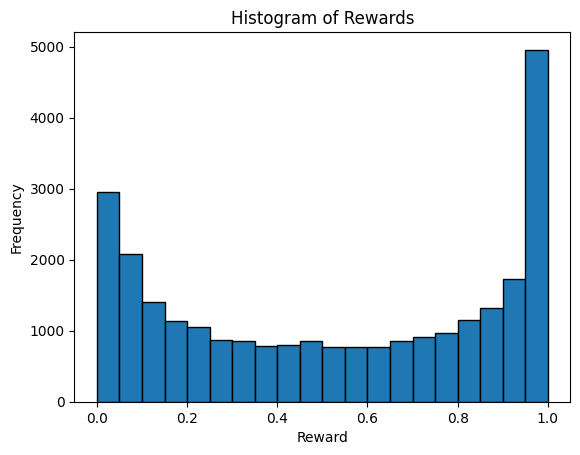

In [18]:
# reward histogram
import matplotlib.pyplot as plt

plt.hist(final_df['reward'], bins=20, edgecolor='black')
plt.title('Histogram of Rewards')
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.show()


In [25]:
import numpy as np
import pandas as pd

def undersample_reward_bin(df, reward_col="reward", bin_range=(0.9, 1.0), n_remove=1000, random_state=42):
    """
    Randomly undersamples rows whose reward falls within a given bin range.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    reward_col : str
        Name of the reward column.
    bin_range : tuple(float, float)
        (low, high) range of the reward bin to undersample, inclusive of low and exclusive of high.
    n_remove : int
        Number of rows to randomly remove from that bin.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        DataFrame with rows from the specified bin randomly removed.
    """
    rng = np.random.default_rng(random_state)

    # Identify rows inside the target bin
    bin_mask = (df[reward_col] >= bin_range[0]) & (df[reward_col] < bin_range[1])
    bin_indices = df[bin_mask].index

    # Determine how many to remove (can't remove more than available)
    n_remove = min(n_remove, len(bin_indices))

    if n_remove == 0:
        print("No rows removed: target bin is empty or smaller than n_remove.")
        return df

    # Randomly pick indices to drop
    drop_indices = rng.choice(bin_indices, size=n_remove, replace=False)

    # Return undersampled dataframe
    return df.drop(index=drop_indices).reset_index(drop=True)

undersampled_final_df = undersample_reward_bin(final_df, reward_col="reward", bin_range=(0.95, 1.0), n_remove=2500, random_state=42)
undersampled_final_df = undersample_reward_bin(undersampled_final_df, reward_col="reward", bin_range=(0, 0.05), n_remove=1000, random_state=42)


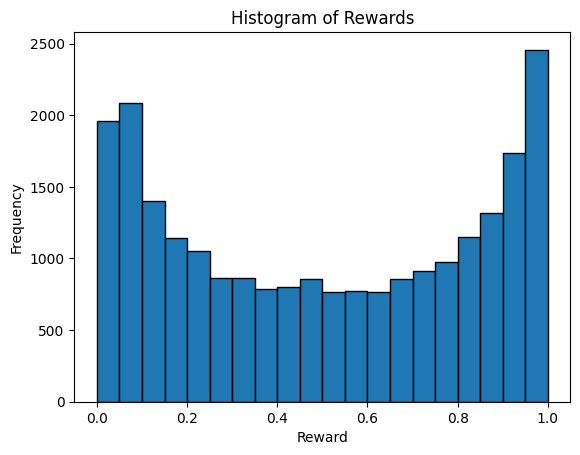

(23521, 15)

In [26]:
# reward histogram
import matplotlib.pyplot as plt

plt.hist(undersampled_final_df['reward'], bins=20, edgecolor='black')
plt.title('Histogram of Rewards')
plt.xlabel('Reward')
plt.ylabel('Frequency')
plt.show()
undersampled_final_df.shape

In [27]:
undersampled_final_df

,doc_id,doc,target,arguments,resps,filtered_resps,filter,metrics,doc_hash,prompt_hash,target_hash,mae,ae,pred,reward
0,0,"{""answer_cot"": ""The meal consists of 100 grams...",90.15,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 97.99}]]","[Answer: {""total_carbohydrates"": 97.99}]",none,"[mae, ae]",6f9c9fa55eb2941ba50d96a2a2807020a637ee8412ede2...,1a923f07f0cb2f1a519cb7b2db61b5c4e43658a41c534b...,e35e6dda3dbab98817ef896acc3c895f430499e90132b2...,7.84,7.84,97.99,0.807815
1,1,"{""answer_cot"": ""The meal consists of 100 grams...",41.67,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 75.0}]]","[Answer: {""total_carbohydrates"": 75.0}]",none,"[mae, ae]",72ba0fc414b6ec44d8a9a575af2d7e03b409d8e57c1bbd...,a6226fa9e36530236f4e3acf52b5ac2f8654c36a75921b...,c27b095c354a3e38732678780c468d773ef82bdbf496c3...,33.33,33.33,75.00,0.021126
2,2,"{""answer_cot"": ""The meal consists of 100 grams...",42.70,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 31.61}]]","[Answer: {""total_carbohydrates"": 31.61}]",none,"[mae, ae]",a7e631b9eab7e4caf2ab3948f40eda26a93787416b830d...,a9cb1373f4ea456fcd0af6e6a62f74a20d428381ed550d...,ff3434be4531634a490c8815ad2e7f2b9061d7e8151f50...,11.09,11.09,31.61,0.652436
3,3,"{""answer_cot"": ""The meal consists of 153 grams...",8.23,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 22.82}]]","[Answer: {""total_carbohydrates"": 22.82}]",none,"[mae, ae]",3ed8d76ff40857504fe4fea542aecf1ea091397c451565...,9e0c9a650900b697bca80dbacc667645b8e20e74c3f946...,74d3386c4e56de6359f4a9765f8fa6b60bacfe06675130...,14.59,14.59,22.82,0.477531
4,4,"{""answer_cot"": ""The meal consists of a cup of ...",10.20,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 41.43}]]","[Answer: {""total_carbohydrates"": 41.43}]",none,"[mae, ae]",cd11cf5948db45dc5f3085c778f2df465f15eca49d3171...,9e11141d34aeb35a697a5cfb817580ba88fa84b3851b46...,f8fccf7ddb81508bf85fc0a7d12a88437ebe64f4bb2c6e...,31.23,31.23,41.43,0.033827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23516,27021,"{""answer_cot"": ""The meal consists of 100 grams...",60.00,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 75.65}]]","[Answer: {""total_carbohydrates"": 75.65}]",none,"[mae, ae]",5828c4b54a9a15327e1d03b279563e1719e98da9d07978...,8f27aa692b9b4ff54aa1cdc03f9040b9db815013cb2849...,db58b6c40698d7371bbcff35d085e1bac5fa439d0de31e...,15.65,15.65,75.65,0.427233
23517,27022,"{""answer_cot"": ""The meal consists of 100 ml ME...",9.25,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 4.67}]]","[Answer: {""total_carbohydrates"": 4.67}]",none,"[mae, ae]",cc2840db9d7731d36455144b3d9fa16ac8dbc0ceba196d...,9666863408b21f3d2db62ae2d2bba4b1fac8f5179c1567...,8633916dcc564eb3fb8b66b2a8cdbb521038f1b8273c44...,4.58,4.58,4.67,0.929754
23518,27023,"{""answer_cot"": ""The meal consists of 100 grams...",16.17,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 20.37}]]","[Answer: {""total_carbohydrates"": 20.37}]",none,"[mae, ae]",2f231b98777d6ceb34e14a39b1d58c88a59fbb7e08d63c...,f55b28c4899d9b5a442fead6da8060f79e135e5f3986e8...,e5e39d8f04c06caea1392c90edfa641065293c3890fd19...,4.20,4.20,20.37,0.940588
23519,27024,"{""answer_cot"": ""The meal consists of 105g oat ...",55.97,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 63.93}]]","[Answer: {""total_carbohydrates"": 63.93}]",none,"[mae, ae]",54ed6920d5465b95285e2cdfcee97ec44562c87d9c6da1...,6c214e2565fed712a45364df3406060c96899ed4105220...,e0cb142a888da756ccff9bd861afbf5e4db7cbf68c58ca...,7.96,7.96,63.93,0.802514


In [28]:
undersampled_final_df['query'] = df['doc'].apply(lambda x: x.get('meal_description') if isinstance(x, dict) else None)


In [29]:
undersampled_final_df['response'] = df['filtered_resps'].apply(lambda x: x[0])

In [34]:
data_dir = '/data/qs4-data2/PPO-with-Confidence/data'
undersampled_final_df.to_json(f"{data_dir}/uniform_reward_{undersampled_final_df.shape[0]}.jsonl", lines=True, orient="records")

In [35]:
f"{data_dir}/uniform_reward_{undersampled_final_df.shape[0]}.jsonl"

'/data/qs4-data2/PPO-with-Confidence/data/uniform_reward_23521.jsonl'

In [31]:
undersampled_final_df

,doc_id,doc,target,arguments,resps,filtered_resps,filter,metrics,doc_hash,prompt_hash,target_hash,mae,ae,pred,reward,query,response
0,0,"{""answer_cot"": ""The meal consists of 100 grams...",90.15,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 97.99}]]","[Answer: {""total_carbohydrates"": 97.99}]",none,"[mae, ae]",6f9c9fa55eb2941ba50d96a2a2807020a637ee8412ede2...,1a923f07f0cb2f1a519cb7b2db61b5c4e43658a41c534b...,e35e6dda3dbab98817ef896acc3c895f430499e90132b2...,7.84,7.84,97.99,0.807815,Enjoying a portion of SONNY & JOE'S HUMMUS GAL...,"Answer: {""total_carbohydrates"": 92.0}"
1,1,"{""answer_cot"": ""The meal consists of 100 grams...",41.67,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 75.0}]]","[Answer: {""total_carbohydrates"": 75.0}]",none,"[mae, ae]",72ba0fc414b6ec44d8a9a575af2d7e03b409d8e57c1bbd...,a6226fa9e36530236f4e3acf52b5ac2f8654c36a75921b...,c27b095c354a3e38732678780c468d773ef82bdbf496c3...,33.33,33.33,75.00,0.021126,I possess 100 grams of Earl Grey black tea in ...,"Answer: {""total_carbohydrates"": 75.0}"
2,2,"{""answer_cot"": ""The meal consists of 100 grams...",42.70,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 31.61}]]","[Answer: {""total_carbohydrates"": 31.61}]",none,"[mae, ae]",a7e631b9eab7e4caf2ab3948f40eda26a93787416b830d...,a9cb1373f4ea456fcd0af6e6a62f74a20d428381ed550d...,ff3434be4531634a490c8815ad2e7f2b9061d7e8151f50...,11.09,11.09,31.61,0.652436,"For a snack, I am enjoying 100 grams of peeled...","Answer: {""total_carbohydrates"": 51.3}"
3,3,"{""answer_cot"": ""The meal consists of 153 grams...",8.23,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 22.82}]]","[Answer: {""total_carbohydrates"": 22.82}]",none,"[mae, ae]",3ed8d76ff40857504fe4fea542aecf1ea091397c451565...,9e0c9a650900b697bca80dbacc667645b8e20e74c3f946...,74d3386c4e56de6359f4a9765f8fa6b60bacfe06675130...,14.59,14.59,22.82,0.477531,I placed an order for 153 grams of chicken alo...,"Answer: {""total_carbohydrates"": 9.52}"
4,4,"{""answer_cot"": ""The meal consists of a cup of ...",10.20,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 41.43}]]","[Answer: {""total_carbohydrates"": 41.43}]",none,"[mae, ae]",cd11cf5948db45dc5f3085c778f2df465f15eca49d3171...,9e11141d34aeb35a697a5cfb817580ba88fa84b3851b46...,f8fccf7ddb81508bf85fc0a7d12a88437ebe64f4bb2c6e...,31.23,31.23,41.43,0.033827,A cup of boiled hyacinth beans seasoned with s...,"Answer: {""total_carbohydrates"": 41.43}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23516,27021,"{""answer_cot"": ""The meal consists of 100 grams...",60.00,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 75.65}]]","[Answer: {""total_carbohydrates"": 75.65}]",none,"[mae, ae]",5828c4b54a9a15327e1d03b279563e1719e98da9d07978...,8f27aa692b9b4ff54aa1cdc03f9040b9db815013cb2849...,db58b6c40698d7371bbcff35d085e1bac5fa439d0de31e...,15.65,15.65,75.65,0.427233,"A tuna salad sandwich weighing 300 grams, made...","Answer: {""total_carbohydrates"": 64.49}"
23517,27022,"{""answer_cot"": ""The meal consists of 100 ml ME...",9.25,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 4.67}]]","[Answer: {""total_carbohydrates"": 4.67}]",none,"[mae, ae]",cc2840db9d7731d36455144b3d9fa16ac8dbc0ceba196d...,9666863408b21f3d2db62ae2d2bba4b1fac8f5179c1567...,8633916dcc564eb3fb8b66b2a8cdbb521038f1b8273c44...,4.58,4.58,4.67,0.929754,"100 grams of house dressing, apple cider vinai...","Answer: {""total_carbohydrates"": 3.75}"
23518,27023,"{""answer_cot"": ""The meal consists of 100 grams...",16.17,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,"[[Answer: {""total_carbohydrates"": 20.37}]]","[Answer: {""total_carbohydrates"": 20.37}]",none,"[mae, ae]",2f231b98777d6ceb34e14a39b1d58c88a59fbb7e08d63c...,f55b28c4899d9b5a442fead6da8060f79e135e5f3986e8...,

In [32]:
path = '/data/qs4-data2/PPO-with-Confidence/data/uniform_reward_45873.jsonl'
with open(path, "r", encoding="utf-8") as f:
    data = [json.loads(l) for l in f if l.strip()] if path.endswith(".json") else json.load(f)

JSONDecodeError: Extra data: line 2 column 1 (char 1959)

In [ ]:
!cat {path}

{"doc_id":0,"doc":{"answer_cot":"The meal consists of a large gluten-free roll.\na large gluten-free roll has 26.24g carbs.\nSo the total carbs in the meal = 26.24.\nOutput: {\"total_carbohydrates\": 26.24}","carb":26.24,"item_id":"nutri_0","meal_description":"A large gluten-free roll is part of my meal."},"target":26.24,"arguments":{"gen_args_0":{"arg_0":"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nYou are a nutrition assistant that estimates carbohydrates from meal descriptions. For the given query including a meal description, respond with the total carbohydrates in grams.}\nImportant:\n- Only use the numeric amount of carbohydrates in your response, without extra text.\n- Do **not** add extra text after the response.\n\nFollow the format of the following examples when answering-\n\nExample 1:\nQuery: \"This morning, I had a cup of oatmeal with h

In [51]:
path = '/data/qs4-data2/PPO-with-Confidence/data/uniform_reward_45873.jsonl'
import pandas as pd
df = pd.read_json(path, lines=True)

In [52]:
df

,doc_id,doc,target,arguments,resps,filtered_resps,filter,metrics,doc_hash,prompt_hash,target_hash,mae,ae,pred,reward,query,response
0,0,{'answer_cot': 'The meal consists of a large g...,26.24,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,[[42.66]],[42.66],none,"[mae, ae]",a11fa9c1890c23d84ed7e8e68fe55541e885495791cba9...,3f18d72e9eeb51e34ffd05e4a0dad79e43ccabbd6bf1b5...,d07bd827f3f53aadb8b3952c74789bae7f8a16e51df412...,16.42,16.42,42.66,0.392128,A large gluten-free roll is part of my meal.,42.66
1,2,{'answer_cot': 'The meal consists of a piece o...,4.75,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,[[15.56]],[15.56],none,"[mae, ae]",e52c5608bdbc026b53eea3e31607da4107fc0379908ca5...,b9b1474d0ae8285c629190b16e382195e0dcff748b34a4...,a0ca9251f1c0a61f78d184dfe82fd1a269e9ac9191e4e2...,10.81,10.81,15.56,0.666477,"For my meal, I am having a single pickled pig'...",1.69
2,3,{'answer_cot': 'The meal consists of a buttern...,0.36,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,[[15.2]],[15.2],none,"[mae, ae]",d98128f8372889b24cce8967236de309ab7594f2036707...,59db40f5f6b31f806d1ed10954b28d0043542e35c1215c...,9c9e5b4a9207b3c014ac5ebe6b6ff68d0fcef40c4c92d5...,14.84,14.84,15.20,0.465486,Enjoying a piece of chocolate candy.,39.96
3,4,{'answer_cot': 'The meal consists of a cup of ...,22.16,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,[[10.84]],[10.84],none,"[mae, ae]",ffdd80842ddfe17b700ddd1a8c97b873ca4149e4f61841...,89001fb5f9319acfb4157a78aa753dd1cbfaac4b0ef444...,3bf4ce291a8a50a336512d1f126082c9dff5397c2f18ca...,11.32,11.32,10.84,0.640863,Consuming dried nutmeat made from butternut.,15.2
4,7,{'answer_cot': 'The meal consists of a slice o...,0.18,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,[[10.77]],[10.77],none,"[mae, ae]",9fbe972b83b3f815a8dcf205830b9ed0d4361d9ca494e6...,43d9615fd28a6b97f719f41057e43ce0ae31da5f825a18...,e6743df815da2b68bf6347dc8821a62d7609faefe384eb...,10.59,10.59,10.77,0.677461,A cup filled with baked cubes of winter hubbar...,12.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45868,22235,{'answer_cot': 'The meal consists of 85 grams ...,0.73,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,[[1.48]],[1.48],none,"[mae, ae]",1c670a89f9f4e4982bceed9ab861248476682094f93a7c...,bcfcc4faa3896eb2a03c59f1f21469d6a24792ad4b233f...,99d03fc3771fe6848d675339fc49eeb1cb8d99a12e6358...,0.75,0.75,1.48,0.998049,Enjoying 100 grams of waffles made from Cinnam...,66.97
45869,23798,{'answer_cot': 'The meal consists of 22 grams ...,0.00,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,[[1.72]],[1.72],none,"[mae, ae]",8c75062ef10a34249c3bd285025f8102d342a1f5af5c89...,53734b7341af99da7083309f1bccf4fbb27f2330e5b8f0...,8aed642bf5118b9d3c859bd4be35ecac75b6e873cce34e...,1.72,1.72,1.72,0.989780,"I am having 85 grams of braised, cooked bonele...",37.96
45870,38706,{'answer_cot': 'The meal consists of 28.35 gra...,0.00,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,[[0.0]],[0.0],none,"[mae, ae]",3c8bc30edc20aa8b0c8b885193873003dfb3b9cef9d882...,301e135642c03c6cd295d4031df0f0fbf39c6d66f42d3c...,8aed642bf5118b9d3c859bd4be35ecac75b6e873cce34e...,0.00,0.00,0.00,1.000000,Enjoying a snack of 100 grams of blueberries c...,101.81
45871,11962,{'answer_cot': 'The meal consists of one fluid...,0.07,{'gen_args_0': {'arg_0': '<|begin_of_text|><|s...,[[2.21 ]],[2.21 ],none,"[mae, ae]",9c4f41180bda10d8d2f028ef7f70a3e6df9dc5abfb9100...,f9e0b7d91b9b9aa1f2c6217575a12ca04ddc8ef92c6832...,91539d7445b231b3612c4f68bd077160bb791bd7b826df...,2.14,2.14,2.21,0.984224,Enjoying a serving of onion rings from a famil...,95.97
